# Firehose 1K — Complete IAA Analysis
**NeurIPS Paper · MPI SWS**

Pipeline:
1. Ines vs adash — before discussion
2. Ines vs adash — after discussion (21 resolved)
3. Tiebreaker — soumidas majority vote on 10 remaining
4. Final stats on all 1000 posts + Bluesky comparison

> **Note on Bluesky comparison**: Bluesky = predicted, Human = ground truth.
> We report **Unsafe-class** precision/recall only (the class of interest).
> Safe-class metrics are not meaningful here.

## 1. Setup

In [1]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

ANN_PATH = "Bluesky Moderation Annotations.csv"
DISAGREE_PATH = "firehose_disagreements_discussion.csv"
POSTS_FH = "firehose_1k_labeled.jsonl"

## 2. Load Data

In [2]:
ann = pd.read_csv(ANN_PATH)
ann.columns = ann.columns.str.strip()
ann = ann.drop_duplicates(subset=['annotator_name','post_id'], keep='last')

# Firehose: Ines and adash only (display_num 10000–20000)
fh = ann[
    (ann['display_num'] >= 10000) &
    (ann['display_num'] <  20000) &
    (ann['annotator_name'].isin(['Ines','adash']))
].copy()

# Tiebreaker: soumidas (display_num 30000–40000)
tb = ann[
    (ann['display_num'] >= 30000) &
    (ann['display_num'] <  40000) &
    (ann['annotator_name'] == 'soumidas')
].copy()

print("Firehose annotations:")
print(fh.groupby('annotator_name').size().to_string())
print(f"\nTiebreaker (soumidas): {len(tb)} posts")

# Load firehose posts (for Bluesky labels)
fh_posts = {}
try:
    with open(POSTS_FH) as f:
        for line in f:
            if line.strip():
                p = json.loads(line)
                if p.get('uri'):
                    fh_posts[p['uri']] = p
    print(f"\nFirehose posts loaded: {len(fh_posts):,}")
    n_bsky = sum(1 for p in fh_posts.values() if p.get('bluesky_labels'))
    print(f"Bluesky-flagged in dataset: {n_bsky}")
except FileNotFoundError:
    print("\nWARNING: Posts file not found — run on server for Bluesky analysis")

def build_lookup(df, name):
    sub = df[df['annotator_name']==name].drop_duplicates('post_id', keep='last')
    return dict(zip(sub['post_id'], sub['label']))

lu_ines  = build_lookup(fh, 'Ines')
lu_adash = build_lookup(fh, 'adash')
lu_tb    = build_lookup(tb, 'soumidas')

common = sorted(set(lu_ines) & set(lu_adash))
print(f"\nInes+adash overlap: {len(common)} posts")


Firehose annotations:
annotator_name
Ines     1000
adash    1000

Tiebreaker (soumidas): 10 posts

Firehose posts loaded: 1,000
Bluesky-flagged in dataset: 6

Ines+adash overlap: 1000 posts


## 3. Label Distribution

In [3]:
dist = fh.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist['total']    = dist.sum(axis=1)
dist['% unsafe'] = (dist.get('Unsafe',0)/dist['total']*100).round(1)
print(dist)

if fh_posts:
    bsky_flagged = sum(1 for p in common if fh_posts.get(p,{}).get('bluesky_labels'))
    print(f"\nBluesky flagged: {bsky_flagged}/{len(common)} ({100*bsky_flagged/len(common):.1f}%)")


label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             980      20   1000       2.0
adash            961      39   1000       3.9

Bluesky flagged: 6/1000 (0.6%)


## 4. Helper Functions

In [4]:
cats = ['Safe', 'Unsafe']

def iaa_stats(common_list, lu_a, lu_b, name_a='Ines', name_b='adash'):
    la = [lu_a[p] for p in common_list]
    lb = [lu_b[p] for p in common_list]
    agree = sum(x==y for x,y in zip(la,lb))
    pct   = 100*agree/len(common_list)
    kappa = cohen_kappa_score(la, lb)
    interp = ('almost perfect' if kappa>=0.8 else 'substantial' if kappa>=0.6
              else 'moderate' if kappa>=0.4 else 'fair' if kappa>=0.2 else 'poor')
    print(f"n={len(common_list)}  agree={agree} ({pct:.1f}%)  κ={kappa:.3f} ({interp})")
    return la, lb, kappa

def bsky_stats(common_list, label_map, annotator_name='Human'):
    """
    Bluesky (predicted) vs Human (ground truth) — Unsafe class only.
    label_map: dict {uri -> 'Safe'|'Unsafe'}
    """
    if not fh_posts:
        print("Bluesky stats not available (posts file not loaded)")
        return None
    y_true = [1 if label_map[p]=='Unsafe' else 0 for p in common_list]
    y_pred = [1 if fh_posts.get(p,{}).get('bluesky_labels') else 0 for p in common_list]

    tp = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==1)
    fp = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==1)
    fn = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==0)
    tn = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==0)

    prec   = tp/(tp+fp) if (tp+fp)>0 else 0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    f1     = 2*prec*recall/(prec+recall) if (prec+recall)>0 else 0

    n_bsky        = sum(y_pred)
    n_human_unsafe= sum(y_true)

    print(f"  Bluesky flagged ({annotator_name} posts):  {n_bsky} ({100*n_bsky/len(y_pred):.1f}%)")
    print(f"  {annotator_name} unsafe:                   {n_human_unsafe} ({100*n_human_unsafe/len(y_true):.1f}%)")
    print(f"  TP (both unsafe):      {tp}")
    print(f"  FN (human only):       {fn}  ← Bluesky missed")
    print(f"  FP (Bluesky only):     {fp}  ← Bluesky false positive")
    print(f"  Precision (Unsafe): {prec:.3f}")
    print(f"  Recall    (Unsafe): {recall:.3f}")
    print(f"  F1        (Unsafe): {f1:.3f}")

    return pd.DataFrame([[tn,fp],[fn,tp]],
        index=['Human: Safe','Human: Unsafe'],
        columns=['Bsky: Safe','Bsky: Unsafe'])

def cm_plot(ax, cm_df, title, cmap):
    sns.heatmap(cm_df, annot=True, fmt='d', cmap=cmap, ax=ax,
                cbar=False, linewidths=0.5, linecolor='white')
    ax.set_title(title)


---
## Part 1 — Before Discussion

In [5]:
print("=== BEFORE DISCUSSION ===\n")
la_b, lb_b, kappa_b = iaa_stats(common, lu_ines, lu_adash)
disagree_before = [p for p in common if lu_ines[p] != lu_adash[p]]
print(f"Disagreements: {len(disagree_before)}")


=== BEFORE DISCUSSION ===

n=1000  agree=969 (96.9%)  κ=0.460 (moderate)
Disagreements: 31


In [6]:
print("\nClassification report (Ines vs adash, before discussion):")
print(classification_report(la_b, lb_b, target_names=['Safe','Unsafe']))



Classification report (Ines vs adash, before discussion):
              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98       980
      Unsafe       0.36      0.70      0.47        20

    accuracy                           0.97      1000
   macro avg       0.68      0.84      0.73      1000
weighted avg       0.98      0.97      0.97      1000



In [7]:
print("\nBluesky vs Ines (before discussion):")
cm_bsky_ines_b = bsky_stats(common, lu_ines, annotator_name='Ines')

print("\nBluesky vs adash (before discussion):")
cm_bsky_adash_b = bsky_stats(common, lu_adash, annotator_name='adash')



Bluesky vs Ines (before discussion):
  Bluesky flagged (Ines posts):  6 (0.6%)
  Ines unsafe:                   20 (2.0%)
  TP (both unsafe):      6
  FN (human only):       14  ← Bluesky missed
  FP (Bluesky only):     0  ← Bluesky false positive
  Precision (Unsafe): 1.000
  Recall    (Unsafe): 0.300
  F1        (Unsafe): 0.462

Bluesky vs adash (before discussion):
  Bluesky flagged (adash posts):  6 (0.6%)
  adash unsafe:                   39 (3.9%)
  TP (both unsafe):      6
  FN (human only):       33  ← Bluesky missed
  FP (Bluesky only):     0  ← Bluesky false positive
  Precision (Unsafe): 1.000
  Recall    (Unsafe): 0.154
  F1        (Unsafe): 0.267


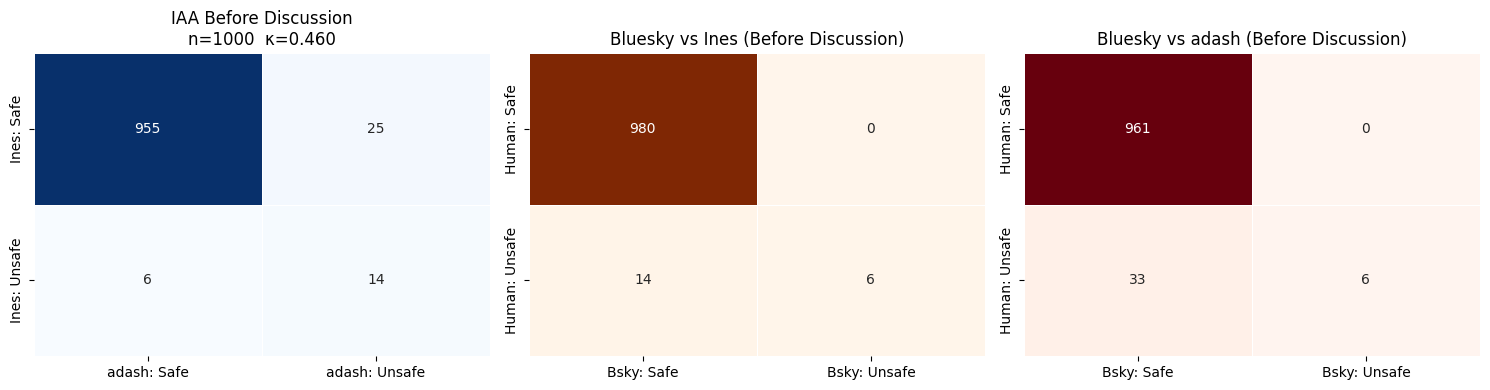

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# IAA confusion matrix
cm_b = confusion_matrix(la_b, lb_b, labels=cats)
cm_plot(axes[0],
    pd.DataFrame(cm_b,
        index=['Ines: Safe','Ines: Unsafe'],
        columns=['adash: Safe','adash: Unsafe']),
    f'IAA Before Discussion\nn={len(common)}  κ={kappa_b:.3f}',
    'Blues')

# Bluesky vs Ines
if fh_posts and cm_bsky_ines_b is not None:
    cm_plot(axes[1], cm_bsky_ines_b,
        'Bluesky vs Ines (Before Discussion)',
        'Oranges')
else:
    axes[1].axis('off')

# Bluesky vs adash
if fh_posts and cm_bsky_adash_b is not None:
    cm_plot(axes[2], cm_bsky_adash_b,
        'Bluesky vs adash (Before Discussion)',
        'Reds')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.savefig('fh_before_discussion.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 2 — After Discussion

In [9]:
disagree_df = pd.read_csv(DISAGREE_PATH)
disagree_df['Ines_label']  = disagree_df['Ines_label'].str.strip().str.capitalize()
disagree_df['adash_label'] = disagree_df['adash_label'].str.strip().str.capitalize()

resolved     = disagree_df[disagree_df['Ines_label'] == disagree_df['adash_label']]
still        = disagree_df[disagree_df['Ines_label'] != disagree_df['adash_label']]
resolved_map = dict(zip(resolved['uri'], resolved['Ines_label']))
still_uris   = set(still['uri'])

print(f"Original disagreements: {len(disagree_df)}")
print(f"Resolved:               {len(resolved)}")
print(f"Still unresolved:       {len(still)}\n")
print("Resolved breakdown (what label was agreed on):")
print(resolved['Ines_label'].value_counts().to_string())


Original disagreements: 31
Resolved:               21
Still unresolved:       10

Resolved breakdown (what label was agreed on):
Ines_label
Safe      15
Unsafe     6


In [10]:
# Override resolved posts with agreed label, keep original for unresolved
lu_ines_post  = {p: resolved_map.get(p, lu_ines[p])  for p in common}
lu_adash_post = {p: resolved_map.get(p, lu_adash[p]) for p in common}

print("=== AFTER DISCUSSION (n=1000, incl. 10 still unresolved) ===\n")
la_a, lb_a, kappa_a = iaa_stats(common, lu_ines_post, lu_adash_post)


=== AFTER DISCUSSION (n=1000, incl. 10 still unresolved) ===

n=1000  agree=990 (99.0%)  κ=0.795 (substantial)


In [11]:
print("\nClassification report (after discussion):")
print(classification_report(la_a, lb_a, target_names=['Safe','Unsafe']))



Classification report (after discussion):
              precision    recall  f1-score   support

        Safe       1.00      0.99      0.99       977
      Unsafe       0.74      0.87      0.80        23

    accuracy                           0.99      1000
   macro avg       0.87      0.93      0.90      1000
weighted avg       0.99      0.99      0.99      1000



In [12]:
print("\nBluesky vs Ines (after discussion):")
cm_bsky_ines_a = bsky_stats(common, lu_ines_post, annotator_name='Ines')

print("\nBluesky vs adash (after discussion):")
cm_bsky_adash_a = bsky_stats(common, lu_adash_post, annotator_name='adash')



Bluesky vs Ines (after discussion):
  Bluesky flagged (Ines posts):  6 (0.6%)
  Ines unsafe:                   23 (2.3%)
  TP (both unsafe):      6
  FN (human only):       17  ← Bluesky missed
  FP (Bluesky only):     0  ← Bluesky false positive
  Precision (Unsafe): 1.000
  Recall    (Unsafe): 0.261
  F1        (Unsafe): 0.414

Bluesky vs adash (after discussion):
  Bluesky flagged (adash posts):  6 (0.6%)
  adash unsafe:                   27 (2.7%)
  TP (both unsafe):      6
  FN (human only):       21  ← Bluesky missed
  FP (Bluesky only):     0  ← Bluesky false positive
  Precision (Unsafe): 1.000
  Recall    (Unsafe): 0.222
  F1        (Unsafe): 0.364


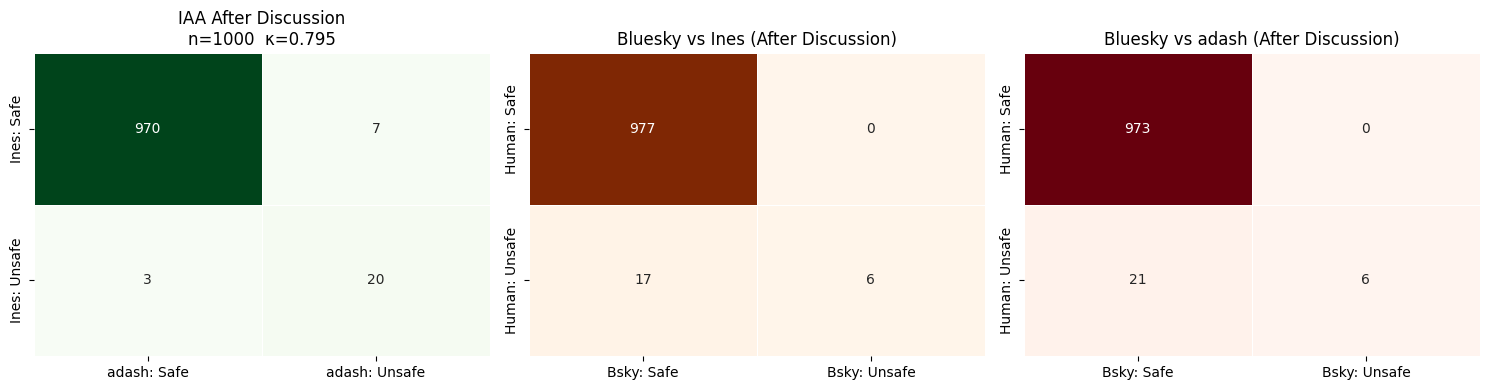

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

cm_a = confusion_matrix(la_a, lb_a, labels=cats)
cm_plot(axes[0],
    pd.DataFrame(cm_a,
        index=['Ines: Safe','Ines: Unsafe'],
        columns=['adash: Safe','adash: Unsafe']),
    f'IAA After Discussion\nn={len(common)}  κ={kappa_a:.3f}',
    'Greens')

if fh_posts and cm_bsky_ines_a is not None:
    cm_plot(axes[1], cm_bsky_ines_a,
        'Bluesky vs Ines (After Discussion)',
        'Oranges')
else:
    axes[1].axis('off')

if fh_posts and cm_bsky_adash_a is not None:
    cm_plot(axes[2], cm_bsky_adash_a,
        'Bluesky vs adash (After Discussion)',
        'Reds')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.savefig('fh_after_discussion.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 3 — Tiebreaker (soumidas on 10 unresolved posts)

In [14]:
print(f"=== TIEBREAKER — soumidas on {len(still_uris)} posts ===\n")

final_tb = {}
tb_rows  = []
for uri in sorted(still_uris):
    i = lu_ines.get(uri, '?')
    a = lu_adash.get(uri, '?')
    s = lu_tb.get(uri, None)
    votes    = [i, a] + ([s] if s else [])
    majority = 'Unsafe' if votes.count('Unsafe') > votes.count('Safe') else 'Safe'
    final_tb[uri] = majority
    tb_rows.append({
        'Ines': i, 'adash': a,
        'soumidas': s if s else '—',
        'majority': majority,
        'text': str(fh_posts.get(uri,{}).get('text',''))[:80] if fh_posts else ''
    })

tb_df = pd.DataFrame(tb_rows)
print(tb_df[['Ines','adash','soumidas','majority','text']].to_string(index=False))
print(f"\nMajority → Unsafe: {(tb_df['majority']=='Unsafe').sum()}")
print(f"Majority → Safe:   {(tb_df['majority']=='Safe').sum()}")


=== TIEBREAKER — soumidas on 10 posts ===

  Ines  adash soumidas majority                                                                               text
  Safe Unsafe   Unsafe   Unsafe   I am against any type of violence or discrimination. But i am NOT going to suppo
Unsafe   Safe     Safe     Safe   "You won't need food when you're BURNING IN HELL! Don't forget..God loves you...
  Safe Unsafe   Unsafe   Unsafe   I remember when there was a mass shooting and a POTUS would try to comfort the c
  Safe Unsafe   Unsafe   Unsafe   African and Asian societies tend to be far less socially atomized, and in some c
  Safe Unsafe     Safe     Safe  Möge ihnen auch das Hirn abfrieren, aber warte 🤔.\nWo nichts ist was soll da abfr
  Safe Unsafe   Unsafe   Unsafe                                                        youtube.com/shorts/jHODb...
  Safe Unsafe   Unsafe   Unsafe                                                                      🥚🥚👃🍆😮🍑✊👅🍆✊💦🦶🐽
Unsafe   Safe     Safe     Safe A pho

---
## Part 4 — Final Stats (all 1000 posts)

In [15]:
# Build final label map
# - Posts that were originally agreed: keep original label
# - Posts resolved in discussion: use agreed label
# - Posts resolved by tiebreaker: use majority vote
final_map = {}
for p in common:
    if p in final_tb:
        final_map[p] = final_tb[p]
    elif p in resolved_map:
        final_map[p] = resolved_map[p]
    else:
        final_map[p] = lu_ines[p]  # originally agreed → same for both

n_unsafe = sum(1 for v in final_map.values() if v=='Unsafe')
n_safe   = len(final_map) - n_unsafe

print(f"=== FINAL LABEL DISTRIBUTION (n={len(final_map)}) ===")
print(f"  Unsafe: {n_unsafe} ({100*n_unsafe/len(final_map):.1f}%)")
print(f"  Safe:   {n_safe}  ({100*n_safe/len(final_map):.1f}%)")
print(f"\nHow labels were determined:")
print(f"  Originally agreed (no discussion needed): {len(common)-len(disagree_df)}")
print(f"  Resolved through discussion:              {len(resolved)}")
print(f"  Resolved through tiebreaker:              {len(final_tb)}")


=== FINAL LABEL DISTRIBUTION (n=1000) ===
  Unsafe: 27 (2.7%)
  Safe:   973  (97.3%)

How labels were determined:
  Originally agreed (no discussion needed): 969
  Resolved through discussion:              21
  Resolved through tiebreaker:              10


In [16]:
# Each annotator vs final consensus
print("=== ANNOTATOR vs FINAL CONSENSUS ===\n")
for name, lu in [('Ines', lu_ines), ('adash', lu_adash)]:
    la_f = [lu[p]         for p in common]
    lb_f = [final_map[p]  for p in common]
    ag   = sum(x==y for x,y in zip(la_f, lb_f))
    k    = cohen_kappa_score(la_f, lb_f)
    print(f"{name} vs final consensus:")
    print(f"  Agreement: {ag}/{len(common)} ({100*ag/len(common):.1f}%)  κ={k:.3f}\n")


=== ANNOTATOR vs FINAL CONSENSUS ===

Ines vs final consensus:
  Agreement: 985/1000 (98.5%)  κ=0.673

adash vs final consensus:
  Agreement: 984/1000 (98.4%)  κ=0.750



In [17]:
print("=== BLUESKY vs FINAL CONSENSUS (Unsafe class only) ===\n")
cm_bsky_f = bsky_stats(common, final_map, annotator_name='Final consensus')
if cm_bsky_f is not None:
    print(f"\nConfusion matrix:")
    print(cm_bsky_f.to_string())


=== BLUESKY vs FINAL CONSENSUS (Unsafe class only) ===

  Bluesky flagged (Final consensus posts):  6 (0.6%)
  Final consensus unsafe:                   27 (2.7%)
  TP (both unsafe):      6
  FN (human only):       21  ← Bluesky missed
  FP (Bluesky only):     0  ← Bluesky false positive
  Precision (Unsafe): 1.000
  Recall    (Unsafe): 0.222
  F1        (Unsafe): 0.364

Confusion matrix:
               Bsky: Safe  Bsky: Unsafe
Human: Safe           973             0
Human: Unsafe          21             6


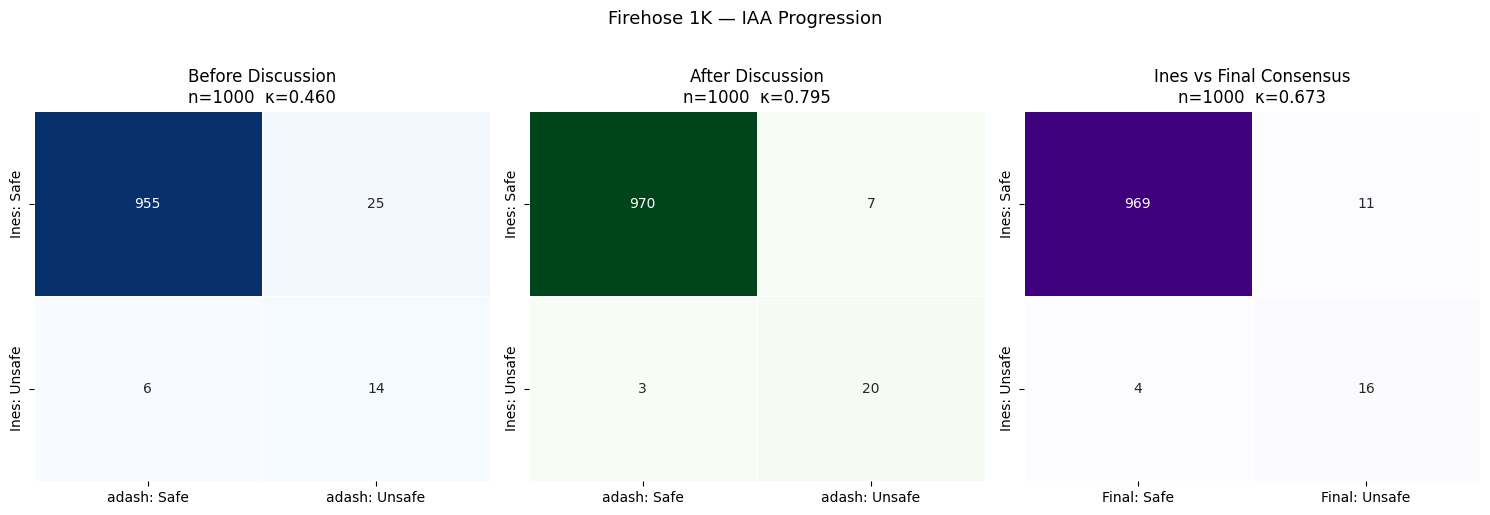

In [18]:
# ── 3-panel progression plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before
cm_b = confusion_matrix(la_b, lb_b, labels=cats)
cm_plot(axes[0],
    pd.DataFrame(cm_b,
        index=['Ines: Safe','Ines: Unsafe'],
        columns=['adash: Safe','adash: Unsafe']),
    f'Before Discussion\nn={len(common)}  κ={kappa_b:.3f}',
    'Blues')

# After
cm_a = confusion_matrix(la_a, lb_a, labels=cats)
cm_plot(axes[1],
    pd.DataFrame(cm_a,
        index=['Ines: Safe','Ines: Unsafe'],
        columns=['adash: Safe','adash: Unsafe']),
    f'After Discussion\nn={len(common)}  κ={kappa_a:.3f}',
    'Greens')

# Ines vs final
la_f = [lu_ines[p]  for p in common]
lb_f = [final_map[p] for p in common]
k_f  = cohen_kappa_score(la_f, lb_f)
cm_f = confusion_matrix(la_f, lb_f, labels=cats)
cm_plot(axes[2],
    pd.DataFrame(cm_f,
        index=['Ines: Safe','Ines: Unsafe'],
        columns=['Final: Safe','Final: Unsafe']),
    f'Ines vs Final Consensus\nn={len(common)}  κ={k_f:.3f}',
    'Purples')

plt.suptitle('Firehose 1K — IAA Progression', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fh_iaa_progression.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Stage': 'Before discussion',  'n': len(common), 'Agreement (%)': round(100*sum(x==y for x,y in zip(la_b,lb_b))/len(common),1), "Cohen's κ": round(kappa_b,3)},
    {'Stage': 'After discussion',   'n': len(common), 'Agreement (%)': round(100*sum(x==y for x,y in zip(la_a,lb_a))/len(common),1), "Cohen's κ": round(kappa_a,3)},
    {'Stage': 'Ines vs consensus',  'n': len(common), 'Agreement (%)': round(100*sum(x==y for x,y in zip(la_f,lb_f))/len(common),1), "Cohen's κ": round(k_f,3)},
])
print(summary.to_string(index=False))


            Stage    n  Agreement (%)  Cohen's κ
Before discussion 1000           96.9      0.460
 After discussion 1000           99.0      0.795
Ines vs consensus 1000           98.5      0.673


In [20]:
rows = []
for p in common:
    post = fh_posts.get(p, {}) if fh_posts else {}
    ines_row = (
        fh[fh["post_id"] == p][fh["annotator_name"] == "Ines"].iloc[0]
        if len(fh[(fh["post_id"] == p) & (fh["annotator_name"] == "Ines")])
        else None
    )
    adash_row = (
        fh[fh["post_id"] == p][fh["annotator_name"] == "adash"].iloc[0]
        if len(fh[(fh["post_id"] == p) & (fh["annotator_name"] == "adash")])
        else None
    )
    rows.append(
        {
            "uri": p,
            "text": str(post.get("text", ""))[:300],
            "final_label": final_map[p],
            "Ines_label": lu_ines[p],
            "Ines_reason": ines_row["reason"] if ines_row is not None else "",
            "Ines_categories": (
                ines_row["unsafe_categories"] if ines_row is not None else ""
            ),
            "adash_label": lu_adash[p],
            "adash_reason": adash_row["reason"] if adash_row is not None else "",
            "adash_categories": (
                adash_row["unsafe_categories"] if adash_row is not None else ""
            ),
            "soumidas_tb": lu_tb.get(p, ""),
            "bluesky_labels": ",".join(post.get("bluesky_labels", [])),
            "how_determined": (
                "tiebreaker"
                if p in final_tb
                else "discussion" if p in resolved_map else "original_agreement"
            ),
        }
    )
final_df = pd.DataFrame(rows)
final_df.to_csv("firehose_final_labels.csv", index=False)
print(f"Saved {len(final_df)} posts → firehose_final_labels.csv")
print(final_df["final_label"].value_counts().to_string())
print(f"\nHow determined:")
print(final_df["how_determined"].value_counts().to_string())
final_df.head()

Saved 1000 posts → firehose_final_labels.csv
final_label
Safe      973
Unsafe     27

How determined:
how_determined
original_agreement    969
discussion             21
tiebreaker             10


,uri,text,final_label,Ines_label,Ines_reason,Ines_categories,adash_label,adash_reason,adash_categories,soumidas_tb,bluesky_labels,how_determined
0,at://did:plc:223sh4mm53etvqw2kojgqjtb/app.bsky...,on.soundcloud.com/vkLRCrh3PMtP...,Safe,Safe,no signs if injury looks sleeping,NaN,Safe,NA.,NaN,,,original_agreement
1,at://did:plc:23gwbfxriupqxrkktiqhdhrz/app.bsky...,Pickering's Triangle NGC 6979 part of the Veil...,Safe,Safe,astronomy,NaN,Safe,Research and image.,NaN,,,original_agreement
2,at://did:plc:24w74q2zfkzemkikzweooohi/app.bsky...,Top 5 Vessels in Port at Saint John as of 2025...,Safe,Safe,safe,NaN,Safe,NA.,NaN,,,original_agreement
3,at://did:plc:254fa7kdhbmynkq5de53fcug/app.bsky...,"Playing on Live 88.5 (Ottawa) right now:\n\n""N...",Safe,Safe,safe,NaN,Safe,NA.,NaN,,,original_agreement
4,at://did:plc:27tqpt2e666wikn4glyc7c6g/app.bsky...,サポートでウィシャデル借りてPV-9までは行けたが、PV-10むり,Safe,Safe,safe,NaN,Safe,NA.,NaN,,,original_agreement


---
## Part 5 — Automated vs Manual Label Categories

Bluesky label categories split by type:
- **Automated** (content-based signals): `porn`, `sexual`, `nudity`, `self-harm`, `graphic-media`
- **Manual** (judgment-based): `threat`, `intolerant`, `rude`

For each group: Precision, Recall, F1 (Bluesky=predicted, Human=ground truth).

In [21]:
AUTOMATED_LABELS = {'porn', 'sexual', 'nudity', 'self-harm', 'graphic-media'}
MANUAL_LABELS    = {'threat', 'intolerant', 'rude'}

def bsky_stats_by_group(common_list, label_map, group_labels, group_name, annotator_name='Final'):
    if not fh_posts:
        print("Posts file not loaded")
        return None

    y_true = [1 if label_map[p]=='Unsafe' else 0 for p in common_list]
    # Bluesky predicted = 1 only if it used a label from this group
    y_pred = [1 if any(l in group_labels
                       for l in fh_posts.get(p,{}).get('bluesky_labels',[]))
              else 0
              for p in common_list]

    tp = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==1)
    fp = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==1)
    fn = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==0)
    tn = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==0)

    prec   = tp/(tp+fp) if (tp+fp)>0 else 0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    f1     = 2*prec*recall/(prec+recall) if (prec+recall)>0 else 0

    n_bsky        = sum(y_pred)
    n_human_unsafe= sum(y_true)

    print(f"[{group_name}] vs {annotator_name} (n={len(common_list)}):")
    print(f"  Bluesky flagged ({group_name}): {n_bsky} ({100*n_bsky/len(y_pred):.1f}%)")
    print(f"  {annotator_name} unsafe:        {n_human_unsafe} ({100*n_human_unsafe/len(y_true):.1f}%)")
    print(f"  TP={tp}  FP={fp}  FN={fn}")
    print(f"  Precision: {prec:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}\n")

    return {'group':group_name, 'annotator':annotator_name,
            'n_bsky_flagged':n_bsky, 'n_human_unsafe':n_human_unsafe,
            'TP':tp,'FP':fp,'FN':fn,
            'Precision':round(prec,3),'Recall':round(recall,3),'F1':round(f1,3)}

print("=== AUTOMATED LABELS vs HUMAN ANNOTATIONS ===\n")
rows = []
for name, lu in [('Ines',lu_ines),('adash',lu_adash),('Final consensus',final_map)]:
    r = bsky_stats_by_group(common, lu, AUTOMATED_LABELS, 'Automated', name)
    if r: rows.append(r)

print("\n=== MANUAL LABELS vs HUMAN ANNOTATIONS ===\n")
for name, lu in [('Ines',lu_ines),('adash',lu_adash),('Final consensus',final_map)]:
    r = bsky_stats_by_group(common, lu, MANUAL_LABELS, 'Manual', name)
    if r: rows.append(r)

summary_df = pd.DataFrame(rows)
summary_df


=== AUTOMATED LABELS vs HUMAN ANNOTATIONS ===

[Automated] vs Ines (n=1000):
  Bluesky flagged (Automated): 6 (0.6%)
  Ines unsafe:        20 (2.0%)
  TP=6  FP=0  FN=14
  Precision: 1.000  Recall: 0.300  F1: 0.462

[Automated] vs adash (n=1000):
  Bluesky flagged (Automated): 6 (0.6%)
  adash unsafe:        39 (3.9%)
  TP=6  FP=0  FN=33
  Precision: 1.000  Recall: 0.154  F1: 0.267

[Automated] vs Final consensus (n=1000):
  Bluesky flagged (Automated): 6 (0.6%)
  Final consensus unsafe:        27 (2.7%)
  TP=6  FP=0  FN=21
  Precision: 1.000  Recall: 0.222  F1: 0.364


=== MANUAL LABELS vs HUMAN ANNOTATIONS ===

[Manual] vs Ines (n=1000):
  Bluesky flagged (Manual): 0 (0.0%)
  Ines unsafe:        20 (2.0%)
  TP=0  FP=0  FN=20
  Precision: 0.000  Recall: 0.000  F1: 0.000

[Manual] vs adash (n=1000):
  Bluesky flagged (Manual): 0 (0.0%)
  adash unsafe:        39 (3.9%)
  TP=0  FP=0  FN=39
  Precision: 0.000  Recall: 0.000  F1: 0.000

[Manual] vs Final consensus (n=1000):
  Bluesky flagge

,group,annotator,n_bsky_flagged,n_human_unsafe,TP,FP,FN,Precision,Recall,F1
0,Automated,Ines,6,20,6,0,14,1.0,0.300,0.462
1,Automated,adash,6,39,6,0,33,1.0,0.154,0.267
2,Automated,Final consensus,6,27,6,0,21,1.0,0.222,0.364
3,Manual,Ines,0,20,0,0,20,0.0,0.000,0.000
4,Manual,adash,0,39,0,0,39,0.0,0.000,0.000
5,Manual,Final consensus,0,27,0,0,27,0.0,0.000,0.000


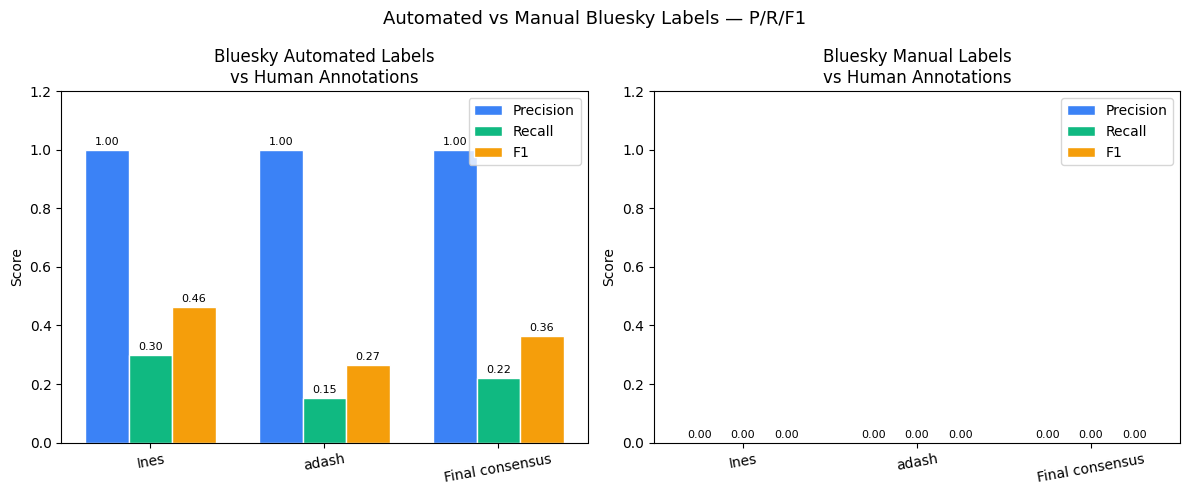

In [22]:
if fh_posts:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, group_name, group_labels, cmap in [
        (axes[0], 'Automated', AUTOMATED_LABELS, 'Blues'),
        (axes[1], 'Manual',    MANUAL_LABELS,    'Oranges'),
    ]:
        annotators = ['Ines','adash','Final consensus']
        label_maps = [lu_ines, lu_adash, final_map]
        precs = []; recs = []; f1s = []
        for lu in label_maps:
            y_true = [1 if lu[p]=='Unsafe' else 0 for p in common]
            y_pred = [1 if any(l in group_labels
                               for l in fh_posts.get(p,{}).get('bluesky_labels',[]))
                      else 0 for p in common]
            tp = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==1)
            fp = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==1)
            fn = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==0)
            prec   = tp/(tp+fp) if (tp+fp)>0 else 0
            recall = tp/(tp+fn) if (tp+fn)>0 else 0
            f1     = 2*prec*recall/(prec+recall) if (prec+recall)>0 else 0
            precs.append(prec); recs.append(recall); f1s.append(f1)

        x = np.arange(len(annotators)); w = 0.25
        ax.bar(x-w, precs, w, label='Precision', color='#3b82f6', edgecolor='white')
        ax.bar(x,   recs,  w, label='Recall',    color='#10b981', edgecolor='white')
        ax.bar(x+w, f1s,   w, label='F1',        color='#f59e0b', edgecolor='white')
        for i,(p,r,f) in enumerate(zip(precs,recs,f1s)):
            for val,off in [(p,-w),(r,0),(f,w)]:
                ax.text(i+off, val+0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(annotators, rotation=10)
        ax.set_ylim(0, 1.2)
        ax.set_ylabel('Score')
        ax.set_title(f'Bluesky {group_name} Labels\nvs Human Annotations')
        ax.legend(loc='upper right')

    plt.suptitle('Automated vs Manual Bluesky Labels — P/R/F1', fontsize=13)
    plt.tight_layout()
    plt.savefig('fh_automated_vs_manual.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Part 6 — Label-Level Confusion Matrix

Full breakdown: which Bluesky labels map to which human categories.
Rows = Bluesky label (or 'none'), Columns = human unsafe_categories.
Ordered: automated first (porn, sexual, nudity, self-harm, graphic-media), manual last (threat, intolerant, rude).

Also shows: posts humans flagged that Bluesky missed entirely.

In [43]:
ORDERED_LABELS = [
    # Automated
    'porn', 'sexual', 'nudity', 'self-harm', 'graphic-media',
    # Manual
    'threat', 'intolerant', 'rude',
    # Other
    'Other', 'none (Bluesky missed)'
]

HUMAN_ORDERED = [
    'S1 (porn)', 'S2 (sexual)', 'S3 (sexual-fig)',
    'S4 (self-harm)', 'S5 (nudity)',
    'S6 (intolerant)', 'S7 (graphic-media)',
    'S8 (rude)', 'S9 (threat)',
    'Other', 'Safe'
]

# Build per-post label pairs using final consensus
# For human categories, use Ines unsafe_categories as proxy
# (can swap to final_map if needed)
fh_ines = fh[fh['annotator_name']=='Ines'].copy()
fh_ines['unsafe_categories'] = fh_ines['unsafe_categories'].fillna('')
cats_ines = dict(zip(fh_ines['post_id'], fh_ines['unsafe_categories']))

rows_detail = []
for p in common:
    bsky  = fh_posts.get(p,{}).get('bluesky_labels',[]) if fh_posts else []
    bsky_lbl = bsky[0] if bsky else 'none (Bluesky missed)'

    human_lbl = final_map[p]
    human_cats = cats_ines.get(p,'')

    rows_detail.append({
        'uri':        p,
        'bsky_label': bsky_lbl,
        'final_label':human_lbl,
        'human_cats': human_cats,
    })

detail_df = pd.DataFrame(rows_detail)
# Build combined categories: join Ines + adash + soumidas (tiebreaker)
fh_ines_cats = fh[fh["annotator_name"] == "Ines"][
    ["post_id", "unsafe_categories"]
].copy()
fh_adash_cats = fh[fh["annotator_name"] == "adash"][
    ["post_id", "unsafe_categories"]
].copy()
tb_soumi_cats = tb[["post_id", "unsafe_categories"]].copy()

fh_ines_cats.columns = ["post_id", "cats_ines"]
fh_adash_cats.columns = ["post_id", "cats_adash"]
tb_soumi_cats.columns = ["post_id", "cats_soumi"]

# Join all three
cats_df = pd.merge(fh_ines_cats, fh_adash_cats, on="post_id", how="outer")
cats_df = pd.merge(cats_df, tb_soumi_cats, on="post_id", how="outer")
cats_df = cats_df.fillna("")


def majority_cats(row):
    uri = row["post_id"]
    if final_map.get(uri, "Safe") == "Safe":
        return ""

    # Collect categories from annotators who said Unsafe
    all_cat_lists = []
    if lu_ines.get(uri) == "Unsafe":
        cats = [
            c.strip()
            for c in str(row["cats_ines"]).split(",")
            if c.strip() and c.strip() != "nan"
        ]
        if cats:
            all_cat_lists.extend(cats)
    if lu_adash.get(uri) == "Unsafe":
        cats = [
            c.strip()
            for c in str(row["cats_adash"]).split(",")
            if c.strip() and c.strip() != "nan"
        ]
        if cats:
            all_cat_lists.extend(cats)
    if lu_tb.get(uri) == "Unsafe":
        cats = [
            c.strip()
            for c in str(row["cats_soumi"]).split(",")
            if c.strip() and c.strip() != "nan"
        ]
        if cats:
            all_cat_lists.extend(cats)

    if not all_cat_lists:
        return ""

    # Count votes per category, keep only those with >= 2 votes
    from collections import Counter

    counts = Counter(all_cat_lists)
    majority = [c for c, n in counts.items() if n >= 2]

    # If no majority, fall back to union
    return (
        ",".join(sorted(majority)) if majority else ",".join(sorted(set(all_cat_lists)))
    )


cats_df["human_cats_combined"] = cats_df.apply(majority_cats, axis=1)

# Join back to detail_df
detail_df = detail_df.merge(
    cats_df[["post_id", "human_cats_combined"]],
    left_on="uri",
    right_on="post_id",
    how="left",
)
detail_df["human_cats"] = detail_df["human_cats_combined"].fillna("")

print("Combined human categories for unsafe posts:")
unsafe_check = detail_df[detail_df["final_label"] == "Unsafe"]
for _, row in unsafe_check.iterrows():
    print(f"  bsky={row['bsky_label']:<25} cats={row['human_cats']!r}")
print(f"Total posts: {len(detail_df)}")
print(f"\nBluesky label distribution:")
print(detail_df['bsky_label'].value_counts().to_string())
print(f"\nFinal human label distribution:")
print(detail_df['final_label'].value_counts().to_string())

Combined human categories for unsafe posts:
  bsky=none (Bluesky missed)     cats='S3'
  bsky=sexual                    cats='S1,S2,S5'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S3'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=none (Bluesky missed)     cats='S2'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=porn                      cats='S5'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S2'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S3'
  bsky=none (Bluesky missed)     cats='S2'
  bsky=porn                      cats='S1'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=porn                      cats='S1'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed)     cats='S3'
  bs

In [39]:
# Posts Bluesky flagged — which human categories were assigned?
bsky_flagged_df = detail_df[detail_df["bsky_label"] != "none (Bluesky missed)"]
bsky_missed_df = detail_df[detail_df["bsky_label"] == "none (Bluesky missed)"]

print(f"Bluesky flagged: {len(bsky_flagged_df)} posts")
print(f"  Human called Unsafe: {(bsky_flagged_df['final_label']=='Unsafe').sum()}")
print(f"  Human called Safe:   {(bsky_flagged_df['final_label']=='Safe').sum()}")
print(f"\nBluesky missed: {len(bsky_missed_df)} posts")
print(f"  Human called Unsafe: {(bsky_missed_df['final_label']=='Unsafe').sum()}")
print(f"  Human called Safe:   {(bsky_missed_df['final_label']=='Safe').sum()}")

print(
    f"\nAmong Bluesky-missed posts humans called UNSAFE — what categories did humans assign?"
)
missed_unsafe = bsky_missed_df[bsky_missed_df["final_label"] == "Unsafe"]
cats_counter = {}
for cats in missed_unsafe["human_cats"]:
    for c in str(cats).split(","):
        c = c.strip()
        if c and c != "nan":
            cats_counter[c] = cats_counter.get(c, 0) + 1
for k, v in sorted(cats_counter.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")

Bluesky flagged: 6 posts
  Human called Unsafe: 6
  Human called Safe:   0

Bluesky missed: 994 posts
  Human called Unsafe: 21
  Human called Safe:   973

Among Bluesky-missed posts humans called UNSAFE — what categories did humans assign?
  S8: 6
  S3: 5
  S6: 5
  S2: 5
  S9: 3
  S1: 2


In [40]:
# ── Label confusion matrix: Bluesky label × human category ───────────────────
# For unsafe posts only
unsafe_df = detail_df[detail_df["final_label"] == "Unsafe"].copy()
print(f"Unsafe posts (final consensus): {len(unsafe_df)}")

# Expand human categories (one row per category)
cat_rows = []
for _, row in unsafe_df.iterrows():
    cats = [
        c.strip()
        for c in str(row["human_cats"]).split(",")
        if c.strip() and c.strip() != "nan"
    ]
    if not cats:
        cats = ["Other"]
    for cat in cats:
        cat_rows.append({"bsky_label": row["bsky_label"], "human_cat": cat})

cat_df = pd.DataFrame(cat_rows)
print(f"\nHuman category distribution (unsafe posts):")
print(cat_df["human_cat"].value_counts().to_string())

Unsafe posts (final consensus): 27

Human category distribution (unsafe posts):
human_cat
S2    10
S1     6
S3     6
S8     6
S6     5
S9     3
S5     2


In [41]:
# Build the cross-tabulation matrix
BSKY_ORDER = [
    "porn",
    "sexual",
    "nudity",
    "self-harm",
    "graphic-media",
    "threat",
    "intolerant",
    "rude",
    "none (Bluesky missed)",
]
# Map human S-codes to readable names
HUMAN_CAT_MAP = {
    "S1": "porn",
    "S2": "sexual",
    "S3": "sexual-fig",
    "S4": "self-harm",
    "S5": "nudity",
    "S6": "intolerant",
    "S7": "graphic-media",
    "S8": "rude",
    "S9": "threat",
    "Other": "Other",
}
HUMAN_ORDER = [
    "porn",
    "sexual",
    "sexual-fig",
    "self-harm",
    "nudity",
    "intolerant",
    "graphic-media",
    "rude",
    "threat",
    "Other",
]

cat_df["human_cat_clean"] = cat_df["human_cat"].map(lambda x: HUMAN_CAT_MAP.get(x, x))

# Only keep known bsky labels
cat_df_known = cat_df[cat_df["bsky_label"].isin(BSKY_ORDER)]

# Cross-tab
cross = pd.crosstab(
    cat_df_known["bsky_label"],
    cat_df_known["human_cat_clean"],
)
# Reindex to our ordered lists
bsky_present = [l for l in BSKY_ORDER if l in cross.index]
human_present = [l for l in HUMAN_ORDER if l in cross.columns]
other_cols = [c for c in cross.columns if c not in human_present]
cross = cross.reindex(
    index=bsky_present, columns=human_present + other_cols, fill_value=0
)

print("Bluesky label (rows) × Human category (cols) — unsafe posts only")
print(cross.to_string())

Bluesky label (rows) × Human category (cols) — unsafe posts only
human_cat_clean        porn  sexual  sexual-fig  nudity  intolerant  rude  threat
bsky_label                                                                       
porn                      3       4           1       1           0     0       0
sexual                    1       1           0       1           0     0       0
none (Bluesky missed)     2       5           5       0           5     6       3


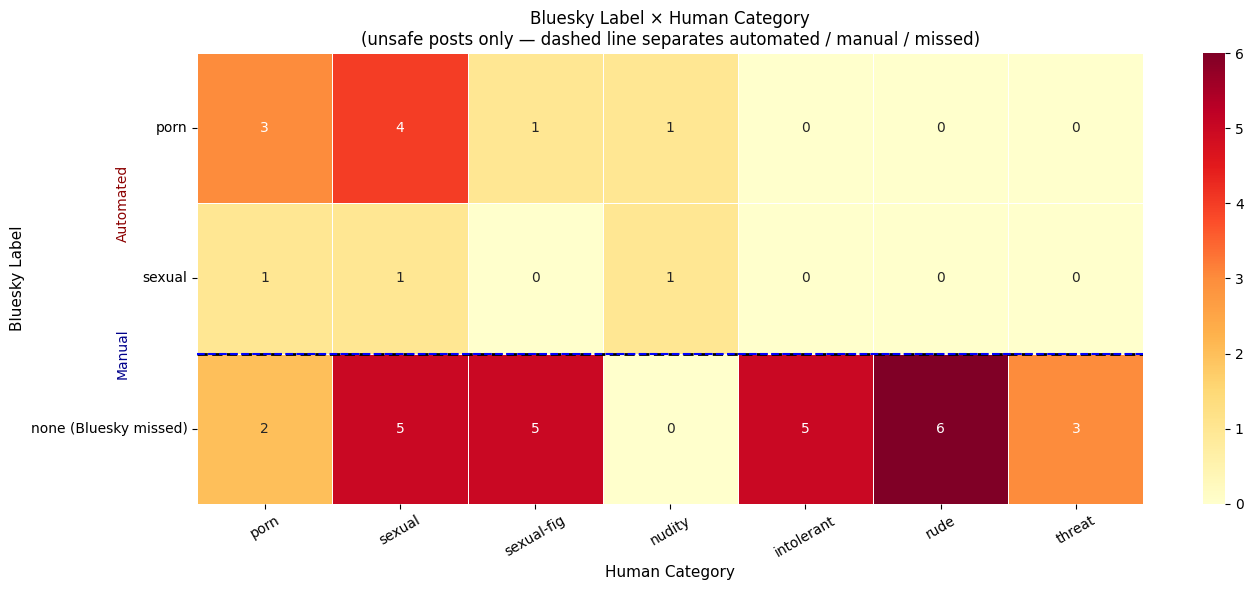

In [42]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Add divider line between automated and manual
n_auto = sum(1 for l in bsky_present
             if l in {'porn','sexual','nudity','self-harm','graphic-media'})

sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', cbar=True)

# Draw separator line between automated and manual rows
ax.axhline(n_auto, color='black', linewidth=2, linestyle='--')
ax.axhline(n_auto + sum(1 for l in bsky_present
                        if l in {'threat','intolerant','rude'}),
           color='blue', linewidth=1.5, linestyle='--')

# Labels
ax.set_xlabel('Human Category', fontsize=11)
ax.set_ylabel('Bluesky Label', fontsize=11)
ax.set_title('Bluesky Label × Human Category\n(unsafe posts only — dashed line separates automated / manual / missed)',
             fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# Annotation: automated vs manual
ax.text(-0.5, n_auto/2, 'Automated', va='center', ha='right',
        fontsize=10, color='darkred', rotation=90, transform=ax.transData)
ax.text(-0.5, n_auto + sum(1 for l in bsky_present if l in {'threat','intolerant','rude'})/2,
        'Manual', va='center', ha='right',
        fontsize=10, color='darkblue', rotation=90, transform=ax.transData)

plt.tight_layout()
plt.savefig('fh_label_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Combined human categories for unsafe posts:
  bsky=none (Bluesky missed)     cats='S1,S3'
  bsky=sexual                    cats='S1,S2,S5'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S3'
  bsky=none (Bluesky missed)     cats='S6,S8'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=none (Bluesky missed)     cats='S2'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=porn                      cats='S5'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S2'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=none (Bluesky missed)     cats='S6'
  bsky=none (Bluesky missed)     cats='S2,S3'
  bsky=none (Bluesky missed)     cats='S1,S2'
  bsky=porn                      cats='S1,S2'
  bsky=none (Bluesky missed)     cats='S8'
  bsky=porn                      cats='S1,S2'
  bsky=none (Bluesky missed)     cats='S9'
  bsky=none (Bluesky missed) 